# CMAPSS Data Understanding

This notebook is intentionally narrow.

This notebook is not about doing every possible time-series diagnostic. It is about answering the questions that control the rest of the project:

- What is the real dataset for RUL learning?
- What is a unit, a cycle, and a target in CMAPSS?
- Which columns are useless, constant, or likely informative?
- What should we be careful about before building features or models?

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("Could not locate the project root containing the src directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import add_train_rul, get_sensor_columns, load_dataset
from src.eda import estimate_sensor_degradation, get_constant_columns, rank_sensor_variability, summarize_cycles

sns.set_theme(style="whitegrid", font_scale=1.0)
DATA_DIR = PROJECT_ROOT / "Data"

## 1. Load the main dataset

Use NASA CMAPSS as the primary dataset for the RUL problem. Synthetic data can wait.

In [10]:
FD = "FD001"
train_df, test_df, rul_df = load_dataset(DATA_DIR, source="nasa", fd=FD)
train_rul_df = add_train_rul(train_df)
sensor_columns = get_sensor_columns(train_df)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)
print("Sensor columns:", len(sensor_columns))
train_df.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)
Sensor columns: 21


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [11]:
print("Train structure:", summarize_cycles(train_df))
print("Test structure:", summarize_cycles(test_df))
print("\nConstant columns:")
print(get_constant_columns(train_df, exclude={"unit", "cycle"}))

missing_counts = train_df.isna().sum()
print("\nMissing values:")
display(missing_counts[missing_counts > 0])

Train structure: {'units': 100, 'min_cycles': 128, 'median_cycles': 199, 'max_cycles': 362}
Test structure: {'units': 100, 'min_cycles': 31, 'median_cycles': 133, 'max_cycles': 303}

Constant columns:
['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Missing values:


Series([], dtype: int64)

## 2. Which sensors look useful?

We want a rough first pass, not a fake certainty. Two useful early heuristics are:

- variability: sensors that actually move
- start-to-end change: sensors that seem to drift as units approach failure

In [12]:
variability = rank_sensor_variability(train_df)
degradation = estimate_sensor_degradation(train_df)

display(variability.head(10))
display(degradation.head(10))

,std,nunique
sensor_9,22.082880,6403.0
sensor_14,19.076176,6078.0
sensor_4,9.000605,4051.0
sensor_3,6.131150,3012.0
sensor_17,1.548763,13.0
sensor_7,0.885092,513.0
sensor_12,0.737553,427.0
sensor_2,0.500053,310.0
sensor_11,0.267087,159.0
sensor_20,0.180746,120.0


,avg_end_minus_start
sensor_9,43.5201
sensor_14,30.6965
sensor_4,28.4353
sensor_3,16.0833
sensor_17,4.5000
sensor_7,-2.6344
sensor_12,-2.2279
sensor_2,1.3246
sensor_11,0.8370
sensor_20,-0.5356


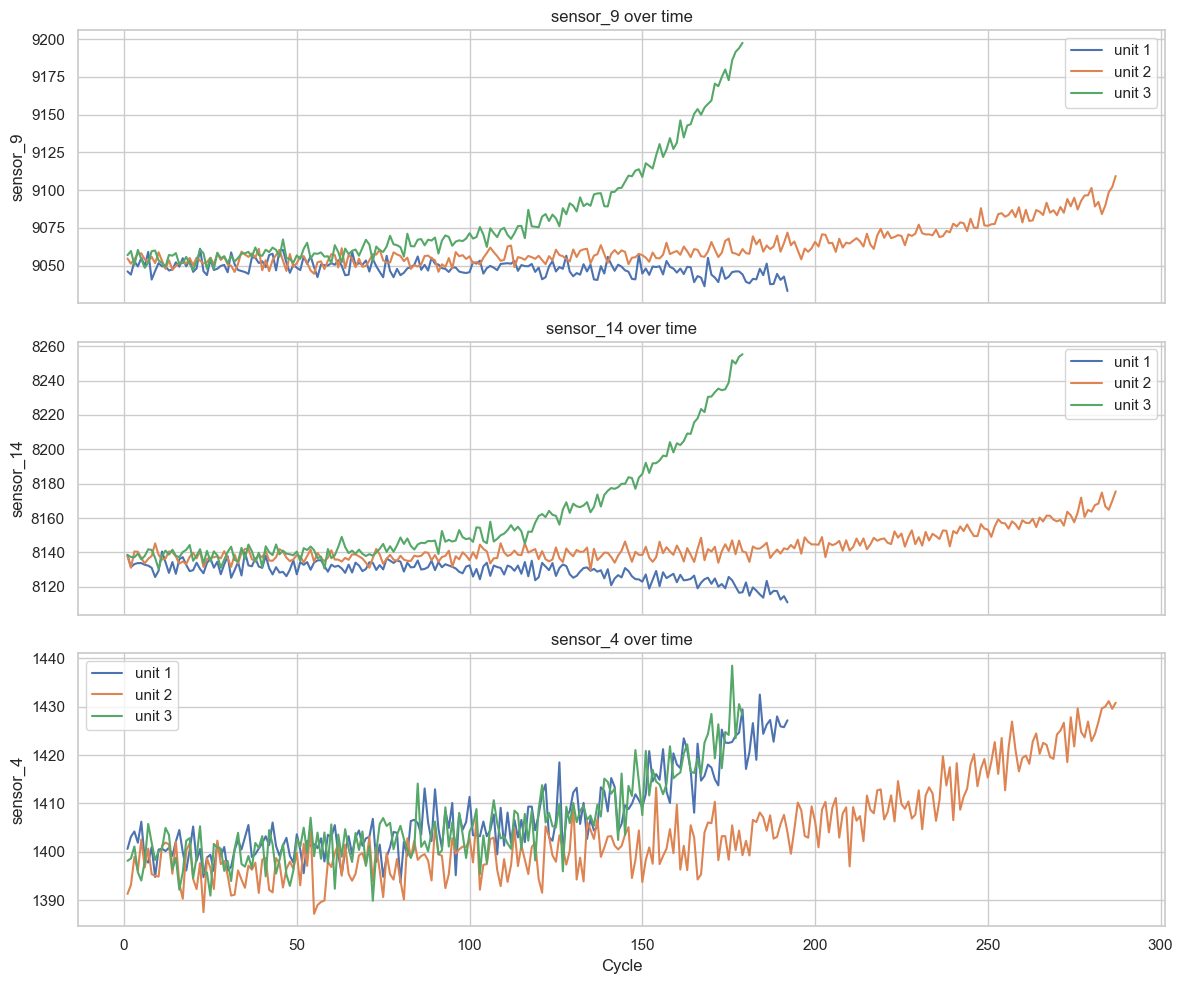

In [13]:
selected_sensors = degradation.head(3).index.tolist()
selected_units = [1, 2, 3]

fig, axes = plt.subplots(len(selected_sensors), 1, figsize=(12, 10), sharex=True)
for ax, sensor in zip(axes, selected_sensors):
    for unit_id in selected_units:
        unit_slice = train_df.loc[train_df["unit"] == unit_id, ["cycle", sensor]]
        ax.plot(unit_slice["cycle"], unit_slice[sensor], label=f"unit {unit_id}")
    ax.set_title(f"{sensor} over time")
    ax.set_ylabel(sensor)
    ax.legend()
axes[-1].set_xlabel("Cycle")
plt.tight_layout()
plt.show()

## 3. What does the target look like?

In train, RUL is derived from the final observed failure cycle of each unit. In test, the sequence is truncated and the true remaining cycles come from the external `RUL_FD001.txt` file.

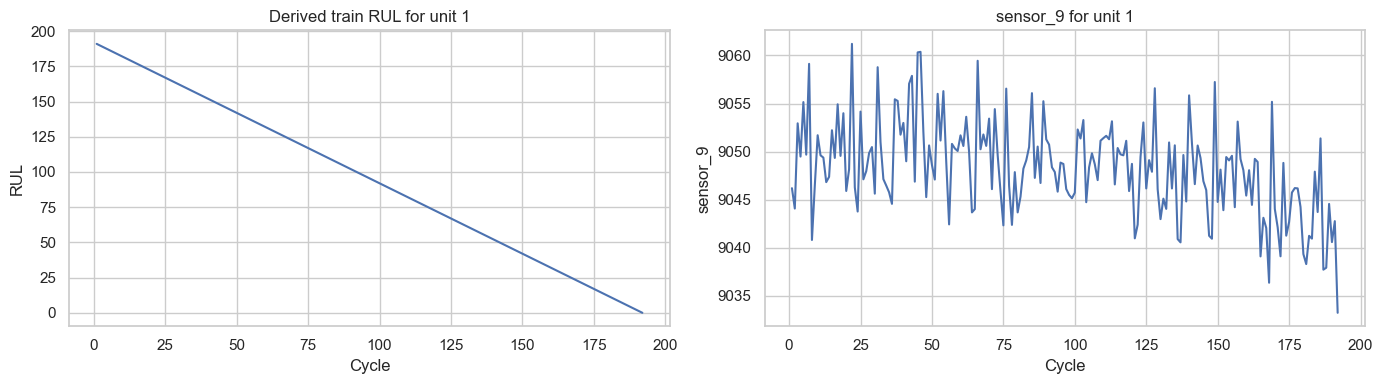

,unit,cycle,rul
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184


In [14]:
sample_unit = 1
unit_slice = train_rul_df.loc[train_rul_df["unit"] == sample_unit, ["cycle", "rul", selected_sensors[0]]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(unit_slice["cycle"], unit_slice["rul"])
axes[0].set_title(f"Derived train RUL for unit {sample_unit}")
axes[0].set_xlabel("Cycle")
axes[0].set_ylabel("RUL")

axes[1].plot(unit_slice["cycle"], unit_slice[selected_sensors[0]])
axes[1].set_title(f"{selected_sensors[0]} for unit {sample_unit}")
axes[1].set_xlabel("Cycle")
axes[1].set_ylabel(selected_sensors[0])
plt.tight_layout()
plt.show()

train_rul_df.loc[train_rul_df["unit"] == sample_unit, ["unit", "cycle", "rul"]].head(8)

## 4. Key decisions

By the end of this notebook, I should be able to say:

- CMAPSS is the main dataset for RUL forecasting.
- Some columns are constant and should not be treated as useful features.
- A few sensors show much stronger degradation patterns than others.
- The train target can be derived, but the test target is external.
- Future work must avoid leakage by splitting and engineering features carefully.

That is enough for a serious first pass on the dataset.